In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
#!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
data = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

## **Question 1**

In [3]:
data

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [4]:
data.isna().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

**The answer is horsepower column**

## **Question 2**

In [5]:
data.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

**The (50% percentile) for horsepower equals 254.0**

## **Question 3**

In [6]:
def get_X_y(data):
    columns = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year','fuel_efficiency_mpg']
    X, y = data[columns].fillna(0).values[:, :4], data[columns].values[:, -1]
    return X, y

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

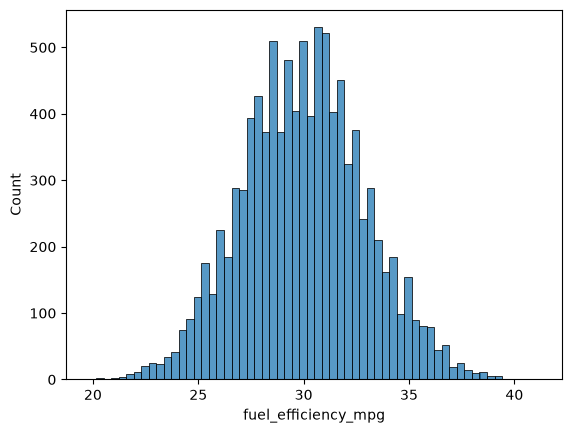

In [7]:
sns.histplot(data['fuel_efficiency_mpg'])

In [8]:
n = len(data)
idx = np.arange(n)

In [9]:
np.random.seed(42)
np.random.shuffle(idx)

In [10]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [11]:
data_val = data.iloc[idx[n_train:n_val + n_train]]
data_test = data.iloc[idx[n_val + n_train:]]
data_train = data.iloc[idx[:n_train]]

In [12]:
data_val = data_val.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)
data_train = data_train.reset_index(drop=True)

In [13]:
data_val

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2004,USA,Gasoline,Rear-wheel drive,3,2240,6,265.0,3990,18.5,30.4
1,2019,Asia,Gasoline,All-wheel drive,5,2390,6,259.0,4770,18.7,32.8
2,2018,USA,Gasoline,Rear-wheel drive,2,2360,6,265.0,4320,19.9,27.8
3,2008,USA,Gasoline,Rear-wheel drive,3,2430,6,279.0,4430,17.9,28.6
4,1999,USA,Gasoline,Front-wheel drive,2,2220,5,249.0,4030,21.0,31.1
...,...,...,...,...,...,...,...,...,...,...,...
1995,2020,Europe,Gasoline,Rear-wheel drive,3,1980,5,229.0,4140,16.7,30.3
1996,1989,USA,Gasoline,All-wheel drive,3,2590,7,263.0,4630,18.8,28.7
1997,2017,USA,Hybrid,Front-wheel drive,3,2390,7,264.0,4550,19.0,30.6
1998,2014,USA,Gasoline,Front-wheel drive,2,2330,6,244.0,4440,19.9,31.0


In [14]:
X_train, y_train = get_X_y(data_train)
X_val, y_val = get_X_y(data_val)
X_test, y_tesr = get_X_y(data_test)

In [15]:
X_train.shape

(6000, 4)

In [16]:
def train_lin_reg(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    w0 = w[0]
    w = w[1:]
    return w0, w

In [17]:
w0_train, w_train = train_lin_reg(X_train, y_train)

In [18]:
w0_train, w_train

(np.float64(-153.88496188223104),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

In [19]:
y_pred_train = X_train.dot(w_train) + w0_train

<Axes: ylabel='Count'>

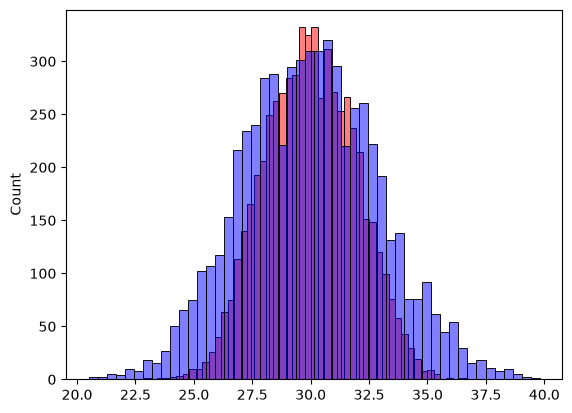

In [20]:
sns.histplot(y_pred_train, color='red', alpha=0.5, bins=50)
#alpha=0.5 - transparency of the color 
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [21]:
y_pred_val = X_val.dot(w_train) + w0_train

In [22]:
def rmse(y_pred, y):
    err = (y_pred - y) ** 2 
    mse = np.mean(err)
    return np.sqrt(mse)

In [23]:
round(rmse(y_pred_train, y_train),3)

np.float64(2.2)

In [24]:
round(rmse(y_pred_val, y_val), 3)

np.float64(2.205)

In [25]:
def get_X_y_no_fill(data):
    columns = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year','fuel_efficiency_mpg']
    X, y = data[columns].values[:, :4], data[columns].values[:, -1]
    return X, y

In [26]:
data_train.horsepower.describe()

count    5462.000000
mean      254.463383
std        22.672546
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [27]:
data_train_mean = data_train.fillna(254.463383)

In [28]:
data_val_mean = data_val.fillna(254.463383)

In [29]:
X_train_mean, y_train_mean = get_X_y_no_fill(data_train_mean)

In [30]:
X_val_mean, y_val_mean = get_X_y_no_fill(data_val_mean)

In [31]:
w0_train_mean, w_train_mean = train_lin_reg(X_train_mean, y_train_mean)

In [32]:
w0_train_mean, w_train_mean

(np.float64(-153.2964564265102),
 array([-0.00102386, -0.00648622, -0.00388828,  0.10197897]))

In [33]:
y_pred_train_mean = X_train_mean.dot(w_train_mean) + w0_train_mean

In [34]:
y_pred_val_mean = X_val_mean.dot(w_train_mean) + w0_train_mean

In [35]:
round(rmse(y_pred_train_mean, y_train_mean), 3)

np.float64(2.198)

In [36]:
round(rmse(y_pred_val_mean, y_val_mean), 3)

np.float64(2.202)

<Axes: ylabel='Count'>

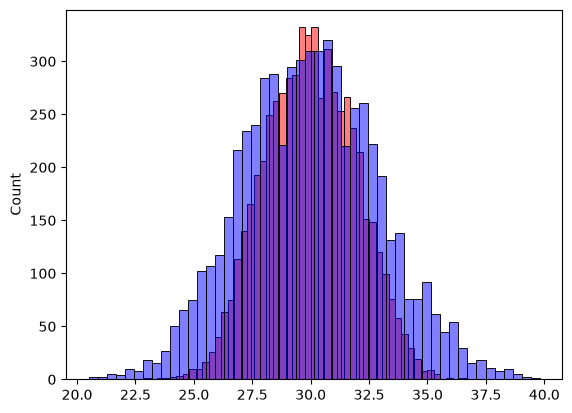

In [37]:
sns.histplot(y_pred_train, color='red', alpha=0.5, bins=50)
#alpha=0.5 - transparency of the color 
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

**RMSE in case of filling with mean is (2.202) it is lower than for filling with 0 (2.205)**

## **Question 4**

In [38]:
r_ = [0, 0.01, 0.1, 1, 5, 10, 100]

In [39]:
def lin_regres_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) 
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)

    w = XTX_inv.dot(X.T).dot(y)

    w0 = w[0]
    w = w[1:]
    return w0, w

In [40]:
X_train, y_train = get_X_y(data_train)
X_val, y_val = get_X_y(data_val)
X_test, y_tesr = get_X_y(data_test)

In [41]:
for r in r_:
    
    w0_train, w_train = lin_regres_reg(X_train, y_train, r)
    
    y_pred_val = X_val.dot(w_train) + w0_train
    
    score = round(rmse(y_pred_val, y_val), 4)
    
    print(f'RMSE: {score}')

RMSE: 2.2053
RMSE: 2.2058
RMSE: 2.2241
RMSE: 2.3492
RMSE: 2.4094
RMSE: 2.4195
RMSE: 2.4292


**The first computation has the lowest RMSE score 2.2053, so the first regularisation temr which is equal 0 is the best**

## **Question 5**

In [42]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [43]:
scores = []

for i in seed:
    np.random.seed(i)
    n = len(data)
    idx = np.arange(n)
    np.random.shuffle(idx)

    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    data_val = data.iloc[idx[n_train:n_val + n_train]]
    data_test = data.iloc[idx[n_val + n_train:]]
    data_train = data.iloc[idx[:n_train]]
    
    data_val = data_val.reset_index(drop=True)
    data_test = data_test.reset_index(drop=True)
    data_train = data_train.reset_index(drop=True)

    X_train, y_train = get_X_y(data_train)
    X_val, y_val = get_X_y(data_val)
    X_test, y_test = get_X_y(data_test)

    w0_train, w_train = train_lin_reg(X_train, y_train)
    
    y_pred_val = X_val.dot(w_train) + w0_train

    score = rmse(y_pred_val, y_val)

    scores.append(score)

In [44]:
scores

[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [45]:
std = round(np.std(scores), 3)

In [46]:
std

np.float64(0.029)

**std = 0.029**

## **Question 6**

In [47]:
np.random.seed(9)
n = len(data)
idx = np.arange(n)
np.random.shuffle(idx)

In [48]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [49]:
data_val = data.iloc[idx[n_train:n_val + n_train]]
data_test = data.iloc[idx[n_val + n_train:]]
data_train = data.iloc[idx[:n_train]]

In [50]:
data_val = data_val.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)
data_train = data_train.reset_index(drop=True)

In [51]:
data_full_train = pd.concat([data_train, data_val])
data_full_train = data_full_train.reset_index(drop=True)

In [52]:
X_full_train, y_full_train = get_X_y(data_full_train)
X_test, y_test = get_X_y(data_test)

In [53]:
w0_train, w_train = lin_regres_reg(X_full_train, y_full_train, r=0.001)

y_pred = X_test.dot(w_train) + w0_train

score = rmse(y_pred, y_test)
round(score, 3)

np.float64(2.236)

**RMSE equals 2.236**